# Dynamic parametrisation accuracy

Simple working notebook for checking one selected Bernese parametrisation from `.OUT` files.

Main modes:

- `ZA` - basic parametrisation, evaluated from ORBGEN fit RMS.
- `ZG` - dynamic parametrisation, evaluated from ORBGEN fit RMS.

Optional mode:

- `ZAZG` - STDDIF comparison between `ZA` and `ZG`.

In [1]:
# ============================================================
# 1) IMPORTS
# ============================================================

import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# doris src
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from doris.input.ssh import download_from_ssh
from doris.input.local import copy_from_local
from doris.analysis.spectral import (
    compute_periodogram,
    estimate_periodogram_threshold,
    find_significant_peaks,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.6f}".format)

print("CWD:", Path.cwd())
print("OK")

CWD: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\notebooks\tests
OK


In [2]:
# ============================================================
# 2) PARAMETERS
# ============================================================

# SUM file — may contain remote OUT paths.
SUM_PATH = Path(r"C:\Users\michal\Desktop\bernese\vysledky\cmorb_SA_ZA_ZG_24_001_030.SUM")

# Select one mode: ZA, ZG, or ZAZG.
SOLUTION = "ZA"

# Satellite and day range.
SAT = "SA"       # SA, S6, J3, or None for all
DOY_FROM = 1
DOY_TO = 30

# ORBGEN iteration for ZA/ZG files.
ITERATION = 2

# Project root — two directories above notebooks/tests/.
_PROJECT_ROOT = Path("../..").resolve()

# Main folder for downloaded OUT files.
DOWNLOAD_DIR = _PROJECT_ROOT / "data" / "bernese"

# Folder for saving plots.
PLOTS_DIR = _PROJECT_ROOT / "LaTeX" / "images" / "test" / "dynamic_precision"

# SSH connection settings.
SSH_HOST = "amalie.pecny.cz"
SSH_PORT = 22
SSH_USERNAME = "mkovar"
SSH_LOGIN_FILE = Path("login_ssh.txt")

# Normalize settings.
SOLUTION = SOLUTION.upper()
if SAT is not None:
    SAT = SAT.upper()

# Create folders.
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("SUM_PATH    :", SUM_PATH, "| exists=", SUM_PATH.exists())
print("SOLUTION    :", SOLUTION)
print("SAT         :", SAT)
print("DOY         :", DOY_FROM, "-", DOY_TO)
print("DOWNLOAD_DIR:", DOWNLOAD_DIR)
print("PLOTS_DIR   :", PLOTS_DIR)

SUM_PATH    : C:\Users\michal\Desktop\bernese\vysledky\cmorb_SA_ZA_ZG_24_001_030.SUM | exists= True
SOLUTION    : ZA
SAT         : SA
DOY         : 1 - 30
DOWNLOAD_DIR: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\bernese
PLOTS_DIR   : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\test\dynamic_precision


In [3]:
# ============================================================
# 3) SSH DOWNLOAD
# ============================================================

# Find remote directory from the SUM file.
_remote_re = re.compile(r"(?P<remote>/\S+/)[A-Za-z0-9]+\d{3}0(?:ZAZG|ZA|ZG)\.OUT", re.I)
_remote_dir = None
if SUM_PATH.exists():
    _m = _remote_re.search(SUM_PATH.read_text(encoding="utf-8", errors="ignore"))
    if _m:
        _remote_dir = _m.group("remote").rstrip("/")

print("Remote dir ze SUM:", _remote_dir)

_sat_pattern = SAT.lower() if SAT else "*"
_out_glob = f"{_sat_pattern}*0{SOLUTION}.OUT"

if not _remote_dir:
    print("Vzdálená složka nenalezena v SUM souboru.")
else:
    result = download_from_ssh(
        host=SSH_HOST,
        port=SSH_PORT,
        username=SSH_USERNAME,
        remote_dir=_remote_dir,
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        login_file=SSH_LOGIN_FILE,
        overwrite=False,
        decompress=False,
        keep_compressed=True,
    )
    print(f"Staženo: {result.count_downloaded}, přeskočeno: {result.count_skipped_existing}")

Remote dir ze SUM: /home/doris/GPSDATA/DORIS_B/OUT


Downloading:   0%|          | 0/30 [00:00<?, ?file/s]

Staženo: 0, přeskočeno: 30


In [4]:
# ============================================================
# 4) CONSOLIDATE LOCAL OUT FILES INTO DOWNLOAD_DIR
# ============================================================

# Pattern matches SA0010ZG.OUT format, excludes ZAZG.
_sat_pattern = SAT.lower() if SAT else "*"
_out_glob = f"{_sat_pattern}*0{SOLUTION}.OUT"

# a) Copy from the SUM folder if different from DOWNLOAD_DIR.
if SUM_PATH.parent.exists() and SUM_PATH.parent.resolve() != DOWNLOAD_DIR.resolve():
    r = copy_from_local(
        source_dir=SUM_PATH.parent,
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        overwrite=False,
    )
    print(f"SUM složka: zkopírováno {r.count_copied}, přeskočeno {r.count_skipped_existing}")

# b) Optional fallback local folder.
_FALLBACK_DIR = None   # e.g. Path(r"C:\old\folder\downloaded_out")
if _FALLBACK_DIR and Path(_FALLBACK_DIR).exists():
    r = copy_from_local(
        source_dir=Path(_FALLBACK_DIR),
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        overwrite=False,
    )
    print(f"Záložní složka: zkopírováno {r.count_copied}, přeskočeno {r.count_skipped_existing}")

# ============================================================
# 5) FIND LOCAL OUT FILES
# ============================================================

out_name_re = re.compile(r"^(?P<sat>[A-Za-z0-9]+?)(?P<doy>\d{3})0(?P<solution>ZAZG|ZA|ZG)\.OUT$", re.I)

_FILE_COLS = ["sat", "doy", "solution", "file", "path", "size_kb"]
rows = []

for path in DOWNLOAD_DIR.glob("*.OUT"):
    m = out_name_re.match(path.name)
    if not m:
        continue

    sat = m.group("sat").upper()
    doy = int(m.group("doy"))
    solution = m.group("solution").upper()

    if solution != SOLUTION:
        continue
    if SAT is not None and sat != SAT:
        continue
    if not (DOY_FROM <= doy <= DOY_TO):
        continue

    rows.append({
        "sat": sat,
        "doy": doy,
        "solution": solution,
        "file": path.name,
        "path": path,
        "size_kb": path.stat().st_size / 1024,
    })

files_df = (
    pd.DataFrame(rows, columns=_FILE_COLS)
    .sort_values(["sat", "doy", "file"])
    .reset_index(drop=True)
)

print(f"Nalezeno souborů: {len(files_df)}")
if not files_df.empty:
    display(files_df)

Copying:   0%|          | 0/1 [00:00<?, ?file/s]

Decompressing:   0%|          | 0/1 [00:00<?, ?file/s]

Skipping decompression for SA0010ZA.OUT: Unsupported compressed file extension: SA0010ZA.OUT


SUM složka: zkopírováno 0, přeskočeno 1
Nalezeno souborů: 30


,sat,doy,solution,file,path,size_kb
0,SA,1,ZA,SA0010ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
1,SA,2,ZA,SA0020ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
2,SA,3,ZA,SA0030ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
3,SA,4,ZA,SA0040ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
4,SA,5,ZA,SA0050ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,341.936523
5,SA,6,ZA,SA0060ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
6,SA,7,ZA,SA0070ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.067383
7,SA,8,ZA,SA0080ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
8,SA,9,ZA,SA0090ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953
9,SA,10,ZA,SA0100ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,342.001953


In [5]:
# ============================================================
# 6) CHECK DAY COVERAGE
# ============================================================

if SAT is None:
    print("SAT=None, přeskočena kontrola pokrytí.")
else:
    expected = pd.DataFrame({
        "sat": SAT,
        "doy": range(DOY_FROM, DOY_TO + 1),
        "solution": SOLUTION,
    })

    coverage_df = expected.merge(
        files_df[["sat", "doy", "solution", "file", "path"]],
        on=["sat", "doy", "solution"],
        how="left",
    )
    coverage_df["found"] = coverage_df["file"].notna()

    print("Očekáváno:", len(coverage_df))
    print("Nalezeno :", int(coverage_df["found"].sum()))
    print("Chybí   :", int((~coverage_df["found"]).sum()))

    display(coverage_df)

Očekáváno: 30
Nalezeno : 30
Chybí   : 0


,sat,doy,solution,file,path,found
0,SA,1,ZA,SA0010ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
1,SA,2,ZA,SA0020ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
2,SA,3,ZA,SA0030ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
3,SA,4,ZA,SA0040ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
4,SA,5,ZA,SA0050ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
5,SA,6,ZA,SA0060ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
6,SA,7,ZA,SA0070ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
7,SA,8,ZA,SA0080ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
8,SA,9,ZA,SA0090ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
9,SA,10,ZA,SA0100ZA.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True


## ORBGEN fit RMS

For `ZA` and `ZG`, the main accuracy indicator in these `.OUT` files is the block `RMS ERRORS AND MAX. RESIDUALS`.

The values are in meters in the file. The notebook converts them to millimeters.


In [6]:
# ============================================================
# 7) PARSE ORBGEN FIT RMS FROM ZA/ZG OUT FILES
# ============================================================

rms_block_re = re.compile(
    r"RMS ERRORS AND MAX\. RESIDUALS\s+ARC NUMBER:\s*(\d+)\s+ITERATION:\s*(\d+)"
    r"(.*?)(?=\n\s*-{5,}\s*\n\s*\n\s*-{5,}\s*\n\s*RPR PARAMETERS|\n\s*RPR PARAMETERS|\Z)",
    re.S,
)

rms_row_re = re.compile(
    r"^\s*(\d+)\s+(\d+)\s+"
    r"([+\-]?\d+\.\d+)\s+"
    r"([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+"
    r"([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s*$",
    re.M,
)


def parse_orbgen_fit_out(path, sat, doy, solution, iteration):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    rows = []

    for block in rms_block_re.finditer(text):
        arc_number = int(block.group(1))
        block_iteration = int(block.group(2))
        if block_iteration != iteration:
            continue

        row = rms_row_re.search(block.group(3))
        if row is None:
            continue

        rows.append({
            "sat": sat,
            "doy": doy,
            "solution": solution,
            "arc_number": arc_number,
            "iteration": block_iteration,
            "bernese_sat_id": int(row.group(1)),
            "n_pos": int(row.group(2)),
            "fit_rms_mm": float(row.group(3)) * 1000.0,
            "total_rms_mm": float(row.group(4)) * 1000.0,
            "radial_rms_mm": float(row.group(5)) * 1000.0,
            "along_rms_mm": float(row.group(6)) * 1000.0,
            "out_rms_mm": float(row.group(7)) * 1000.0,
            "radial_max_mm": float(row.group(8)) * 1000.0,
            "along_max_mm": float(row.group(9)) * 1000.0,
            "out_max_mm": float(row.group(10)) * 1000.0,
            "source_file": Path(path).name,
        })

    return rows


if SOLUTION == "ZAZG":
    fit_arc_df = pd.DataFrame()
    print("SOLUTION=ZAZG -> ORBGEN fit parser přeskočen.")
else:
    all_rows = []
    for _, file_row in files_df.iterrows():
        all_rows.extend(
            parse_orbgen_fit_out(
                file_row["path"],
                sat=file_row["sat"],
                doy=int(file_row["doy"]),
                solution=file_row["solution"],
                iteration=ITERATION,
            )
        )

    fit_arc_df = pd.DataFrame(all_rows)
    if not fit_arc_df.empty:
        fit_arc_df = fit_arc_df.sort_values(["sat", "doy", "arc_number"]).reset_index(drop=True)

    print("Parsed arc rows:", len(fit_arc_df))
    if not fit_arc_df.empty:
        display(fit_arc_df.head(20))

Parsed arc rows: 480


,sat,doy,solution,arc_number,iteration,bernese_sat_id,n_pos,fit_rms_mm,total_rms_mm,radial_rms_mm,along_rms_mm,out_rms_mm,radial_max_mm,along_max_mm,out_max_mm,source_file
0,SA,1,ZA,1,2,926,91,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,SA0010ZA.OUT
1,SA,1,ZA,2,2,926,91,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,SA0010ZA.OUT
2,SA,1,ZA,3,2,926,91,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,2.000000,SA0010ZA.OUT
3,SA,1,ZA,4,2,926,91,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,SA0010ZA.OUT
4,SA,1,ZA,5,2,926,91,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,SA0010ZA.OUT
5,SA,1,ZA,6,2,926,91,1.000000,1.000000,2.000000,1.000000,1.000000,3.000000,3.000000,1.000000,SA0010ZA.OUT
6,SA,1,ZA,7,2,926,91,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,3.000000,SA0010ZA.OUT
7,SA,1,ZA,8,2,926,91,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,SA0010ZA.OUT
8,SA,1,ZA,9,2,926,91,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,4.000000,2.000000,SA0010ZA.OUT
9,SA,1,ZA,10,2,926,91,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,SA0010ZA.OUT


In [7]:
# ============================================================
# 8) DAILY AND GLOBAL SUMMARY
# ============================================================

if fit_arc_df.empty:
    print("fit_arc_df is empty -> nothing to summarize.")
else:
    fit_daily_df = (
        fit_arc_df
        .groupby(["sat", "doy", "solution"], as_index=False)
        .agg(
            arc_count=("arc_number", "count"),
            n_pos_total=("n_pos", "sum"),
            fit_rms_mm_mean=("fit_rms_mm", "mean"),
            total_rms_mm_mean=("total_rms_mm", "mean"),
            radial_rms_mm_mean=("radial_rms_mm", "mean"),
            along_rms_mm_mean=("along_rms_mm", "mean"),
            out_rms_mm_mean=("out_rms_mm", "mean"),
            radial_max_mm_max=("radial_max_mm", "max"),
            along_max_mm_max=("along_max_mm", "max"),
            out_max_mm_max=("out_max_mm", "max"),
        )
        .sort_values(["sat", "doy"])
        .reset_index(drop=True)
    )

    fit_daily_df["rtn_3d_rms_mm"] = np.sqrt(
        fit_daily_df["radial_rms_mm_mean"]**2 +
        fit_daily_df["along_rms_mm_mean"]**2 +
        fit_daily_df["out_rms_mm_mean"]**2
    )

    global_summary = pd.DataFrame([{
        "sat": SAT,
        "solution": SOLUTION,
        "n_days": fit_daily_df["doy"].nunique(),
        "n_arcs": len(fit_arc_df),
        "fit_rms_mm_mean": fit_arc_df["fit_rms_mm"].mean(),
        "total_rms_mm_mean": fit_arc_df["total_rms_mm"].mean(),
        "radial_rms_mm_mean": fit_arc_df["radial_rms_mm"].mean(),
        "along_rms_mm_mean": fit_arc_df["along_rms_mm"].mean(),
        "out_rms_mm_mean": fit_arc_df["out_rms_mm"].mean(),
        "radial_max_mm_max": fit_arc_df["radial_max_mm"].max(),
        "along_max_mm_max": fit_arc_df["along_max_mm"].max(),
        "out_max_mm_max": fit_arc_df["out_max_mm"].max(),
    }])

    display(global_summary)
    display(fit_daily_df.head(30))


,sat,solution,n_days,n_arcs,fit_rms_mm_mean,total_rms_mm_mean,radial_rms_mm_mean,along_rms_mm_mean,out_rms_mm_mean,radial_max_mm_max,along_max_mm_max,out_max_mm_max
0,SA,ZA,30,480,1.022917,1.020833,1.025000,0.881250,0.812500,5.000000,9.000000,23.000000


,sat,doy,solution,arc_count,n_pos_total,fit_rms_mm_mean,total_rms_mm_mean,radial_rms_mm_mean,along_rms_mm_mean,out_rms_mm_mean,radial_max_mm_max,along_max_mm_max,out_max_mm_max,rtn_3d_rms_mm
0,SA,1,ZA,16,1440,1.000000,1.000000,1.000000,0.687500,0.750000,3.000000,4.000000,4.000000,1.426589
1,SA,2,ZA,16,1440,1.000000,1.000000,1.000000,0.812500,0.875000,3.000000,4.000000,15.000000,1.557492
2,SA,3,ZA,16,1440,1.000000,1.000000,1.000000,1.000000,0.750000,4.000000,5.000000,4.000000,1.600781
3,SA,4,ZA,16,1440,1.000000,1.000000,1.000000,0.625000,0.875000,3.000000,5.000000,23.000000,1.468418
4,SA,5,ZA,16,1440,1.000000,1.000000,0.937500,0.812500,0.750000,3.000000,4.000000,9.000000,1.449677
5,SA,6,ZA,16,1440,1.000000,1.000000,1.000000,0.937500,0.812500,4.000000,6.000000,3.000000,1.593444
6,SA,7,ZA,16,1440,0.937500,0.937500,0.937500,0.562500,0.875000,4.000000,5.000000,6.000000,1.400335
7,SA,8,ZA,16,1440,1.000000,1.000000,1.062500,0.875000,0.750000,4.000000,6.000000,4.000000,1.567492
8,SA,9,ZA,16,1440,1.062500,1.000000,1.000000,0.937500,0.687500,5.000000,6.000000,7.000000,1.533481
9,SA,10,ZA,16,1440,1.062500,1.062500,1.187500,0.687500,0.875000,4.000000,7.000000,9.000000,1.627402


In [8]:
# ============================================================
# 9) ORBGEN FIT RMS — SOUHRN
# ============================================================

if fit_arc_df.empty:
    print("fit_arc_df je prázdný.")
else:
    display(global_summary)
    display(fit_daily_df)

,sat,solution,n_days,n_arcs,fit_rms_mm_mean,total_rms_mm_mean,radial_rms_mm_mean,along_rms_mm_mean,out_rms_mm_mean,radial_max_mm_max,along_max_mm_max,out_max_mm_max
0,SA,ZA,30,480,1.022917,1.020833,1.025000,0.881250,0.812500,5.000000,9.000000,23.000000


,sat,doy,solution,arc_count,n_pos_total,fit_rms_mm_mean,total_rms_mm_mean,radial_rms_mm_mean,along_rms_mm_mean,out_rms_mm_mean,radial_max_mm_max,along_max_mm_max,out_max_mm_max,rtn_3d_rms_mm
0,SA,1,ZA,16,1440,1.000000,1.000000,1.000000,0.687500,0.750000,3.000000,4.000000,4.000000,1.426589
1,SA,2,ZA,16,1440,1.000000,1.000000,1.000000,0.812500,0.875000,3.000000,4.000000,15.000000,1.557492
2,SA,3,ZA,16,1440,1.000000,1.000000,1.000000,1.000000,0.750000,4.000000,5.000000,4.000000,1.600781
3,SA,4,ZA,16,1440,1.000000,1.000000,1.000000,0.625000,0.875000,3.000000,5.000000,23.000000,1.468418
4,SA,5,ZA,16,1440,1.000000,1.000000,0.937500,0.812500,0.750000,3.000000,4.000000,9.000000,1.449677
5,SA,6,ZA,16,1440,1.000000,1.000000,1.000000,0.937500,0.812500,4.000000,6.000000,3.000000,1.593444
6,SA,7,ZA,16,1440,0.937500,0.937500,0.937500,0.562500,0.875000,4.000000,5.000000,6.000000,1.400335
7,SA,8,ZA,16,1440,1.000000,1.000000,1.062500,0.875000,0.750000,4.000000,6.000000,4.000000,1.567492
8,SA,9,ZA,16,1440,1.062500,1.000000,1.000000,0.937500,0.687500,5.000000,6.000000,7.000000,1.533481
9,SA,10,ZA,16,1440,1.062500,1.062500,1.187500,0.687500,0.875000,4.000000,7.000000,9.000000,1.627402


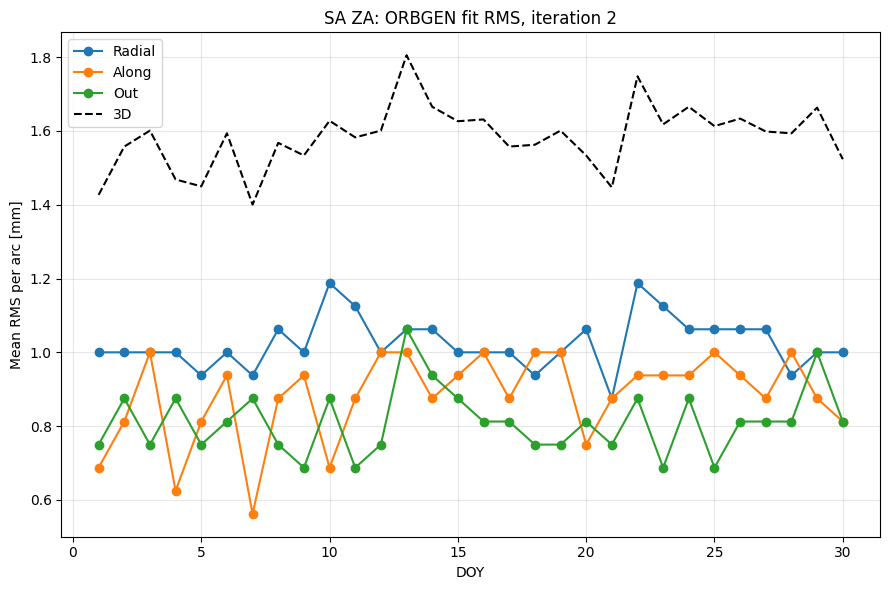

In [9]:
# ============================================================
# 10) PLOTS FOR ZA/ZG FIT ACCURACY
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(fit_daily_df["doy"], fit_daily_df["radial_rms_mm_mean"], "o-", label="Radial")
ax.plot(fit_daily_df["doy"], fit_daily_df["along_rms_mm_mean"], "o-", label="Along")
ax.plot(fit_daily_df["doy"], fit_daily_df["out_rms_mm_mean"], "o-", label="Out")
ax.plot(fit_daily_df["doy"], fit_daily_df["rtn_3d_rms_mm"], "k--", label="3D")
ax.set_xlabel("DOY")
ax.set_ylabel("Mean RMS per arc [mm]")
ax.set_title(f"{SAT or 'ALL'} {SOLUTION}: ORBGEN fit RMS, iteration {ITERATION}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
_sat = (SAT or "all").lower()
fig.savefig(PLOTS_DIR / f"{_sat}_{SOLUTION.lower()}_daily_rms_doy{DOY_FROM:03d}_{DOY_TO:03d}_iter{ITERATION}.pdf", bbox_inches="tight",)
plt.show()

In [10]:
# ============================================================
# 11) PARSE EPOCH RESIDUALS
# ============================================================

residual_block_re = re.compile(
    r"RESIDUALS \(M\)\s+ARC NUMBER:\s*(\d+)\s+ITERATION:\s*(\d+)"
    r"(.*?)(?=\n\s*-{5,}\s*\n\s*\n\s*-{5,}\s*\n\s*RMS ERRORS|\n\s*RMS ERRORS|\Z)",
    re.S,
)

residual_row_re = re.compile(
    r"^\s*(\d{4}-\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2})\s+"
    r"(\d+)\s+([-+]?\d+\.\d+)\s+([-+]?\d+\.\d+)\s+([-+]?\d+\.\d+)\s+"
    r"([-+]?\d+\.\d+)\s+([YN])\s*$",
    re.M,
)


def parse_residual_epochs(path, sat, doy, solution, iteration):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    rows = []

    for block in residual_block_re.finditer(text):
        arc_number = int(block.group(1))
        block_iteration = int(block.group(2))
        if block_iteration != iteration:
            continue

        for m in residual_row_re.finditer(block.group(3)):
            rows.append({
                "sat": sat,
                "doy": doy,
                "solution": solution,
                "arc_number": arc_number,
                "iteration": block_iteration,
                "epoch": pd.to_datetime(m.group(1) + " " + m.group(2)),
                "bernese_sat_id": int(m.group(3)),
                "radial_mm": float(m.group(4)) * 1000.0,
                "along_mm": float(m.group(5)) * 1000.0,
                "out_mm": float(m.group(6)) * 1000.0,
                "int_error_mm": float(m.group(7)) * 1000.0,
                "sun": m.group(8),
                "source_file": Path(path).name,
            })

    return rows


if SOLUTION == "ZAZG":
    residuals_df = pd.DataFrame()
    print("SOLUTION=ZAZG -> residual epoch parser přeskočen.")
else:
    rows = []
    for _, file_row in files_df.iterrows():
        rows.extend(
            parse_residual_epochs(
                file_row["path"],
                sat=file_row["sat"],
                doy=int(file_row["doy"]),
                solution=file_row["solution"],
                iteration=ITERATION,
            )
        )

    residuals_df = pd.DataFrame(rows)
    if not residuals_df.empty:
        residuals_df = residuals_df.sort_values(["sat", "doy", "arc_number", "epoch"]).reset_index(drop=True)
        residuals_df["rtn_3d_mm"] = np.sqrt(
            residuals_df["radial_mm"]**2 + residuals_df["along_mm"]**2 + residuals_df["out_mm"]**2
        )

    print("Parsed residual epochs:", len(residuals_df))
    if not residuals_df.empty:
        display(residuals_df.head(20))

Parsed residual epochs: 43200


,sat,doy,solution,arc_number,iteration,epoch,bernese_sat_id,radial_mm,along_mm,out_mm,int_error_mm,sun,source_file,rtn_3d_mm
0,SA,1,ZA,1,2,2024-01-01 00:00:41,926,0.500000,-1.990000,-0.910000,0.000000,Y,SA0010ZA.OUT,2.244594
1,SA,1,ZA,1,2,2024-01-01 00:01:41,926,-0.060000,-1.610000,-0.500000,0.000000,Y,SA0010ZA.OUT,1.686920
2,SA,1,ZA,1,2,2024-01-01 00:02:41,926,-0.070000,-1.450000,-0.910000,0.000000,Y,SA0010ZA.OUT,1.713330
3,SA,1,ZA,1,2,2024-01-01 00:03:41,926,-0.350000,-0.960000,-0.690000,0.000000,Y,SA0010ZA.OUT,1.232964
4,SA,1,ZA,1,2,2024-01-01 00:04:41,926,-0.110000,-1.220000,-0.040000,0.000000,Y,SA0010ZA.OUT,1.225602
5,SA,1,ZA,1,2,2024-01-01 00:05:41,926,-0.170000,-0.470000,-0.390000,0.000000,Y,SA0010ZA.OUT,0.633956
6,SA,1,ZA,1,2,2024-01-01 00:06:41,926,-0.390000,-0.120000,0.070000,0.000000,Y,SA0010ZA.OUT,0.414005
7,SA,1,ZA,1,2,2024-01-01 00:07:41,926,0.200000,0.070000,0.250000,0.000000,Y,SA0010ZA.OUT,0.327719
8,SA,1,ZA,1,2,2024-01-01 00:08:41,926,-0.260000,0.590000,0.310000,0.000000,Y,SA0010ZA.OUT,0.715402
9,SA,1,ZA,1,2,2024-01-01 00:09:41,926,0.190000,0.480000,-0.160000,0.000000,Y,SA0010ZA.OUT,0.540463


In [11]:
# ============================================================
# 12) RESIDUAL SUMMARY FROM EPOCHS
# ============================================================

def rms_mm(series):
    x = series.to_numpy(dtype=float)
    return float(np.sqrt(np.mean(x**2))) if len(x) else np.nan


if residuals_df.empty:
    print("residuals_df is empty -> nothing to summarize.")
else:
    residual_daily_df = (
        residuals_df
        .groupby(["sat", "doy", "solution"], as_index=False)
        .agg(
            n_epochs=("epoch", "count"),
            radial_mean_mm=("radial_mm", "mean"),
            along_mean_mm=("along_mm", "mean"),
            out_mean_mm=("out_mm", "mean"),
            radial_rms_mm=("radial_mm", rms_mm),
            along_rms_mm=("along_mm", rms_mm),
            out_rms_mm=("out_mm", rms_mm),
            radial_max_abs_mm=("radial_mm", lambda s: s.abs().max()),
            along_max_abs_mm=("along_mm", lambda s: s.abs().max()),
            out_max_abs_mm=("out_mm", lambda s: s.abs().max()),
        )
        .sort_values(["sat", "doy"])
        .reset_index(drop=True)
    )

    residual_daily_df["rtn_3d_rms_mm"] = np.sqrt(
        residual_daily_df["radial_rms_mm"]**2 +
        residual_daily_df["along_rms_mm"]**2 +
        residual_daily_df["out_rms_mm"]**2
    )

    residual_global_summary = pd.DataFrame([{
        "sat": SAT,
        "solution": SOLUTION,
        "iteration": ITERATION,
        "n_epochs": len(residuals_df),
        "radial_rms_mm": rms_mm(residuals_df["radial_mm"]),
        "along_rms_mm": rms_mm(residuals_df["along_mm"]),
        "out_rms_mm": rms_mm(residuals_df["out_mm"]),
        "rtn_3d_rms_mm": rms_mm(residuals_df["rtn_3d_mm"]),
    }])

    display(residual_global_summary)
    display(residual_daily_df)

,sat,solution,iteration,n_epochs,radial_rms_mm,along_rms_mm,out_rms_mm,rtn_3d_rms_mm
0,SA,ZA,2,43200,0.995718,0.830797,0.867336,1.560112


,sat,doy,solution,n_epochs,radial_mean_mm,along_mean_mm,out_mean_mm,radial_rms_mm,along_rms_mm,out_rms_mm,radial_max_abs_mm,along_max_abs_mm,out_max_abs_mm,rtn_3d_rms_mm
0,SA,1,ZA,1440,0.077826,0.000014,0.004625,0.918633,0.634066,0.782437,3.490000,4.400000,3.980000,1.363134
1,SA,2,ZA,1440,0.040542,0.000063,0.009951,0.835262,0.723801,0.917533,3.010000,4.480000,14.850000,1.436460
2,SA,3,ZA,1440,0.030708,0.000083,0.010903,0.976537,0.767006,0.716791,3.780000,4.720000,3.840000,1.433775
3,SA,4,ZA,1440,0.041708,-0.000021,0.004833,0.905268,0.692868,1.029179,3.390000,4.800000,23.130000,1.535834
4,SA,5,ZA,1440,0.022056,-0.000076,0.008729,0.848462,0.744547,0.817524,2.630000,3.970000,8.970000,1.393766
5,SA,6,ZA,1440,0.037417,0.000007,0.011319,0.963841,0.799554,0.709853,3.900000,6.500000,3.050000,1.439502
6,SA,7,ZA,1440,0.066528,-0.000042,0.007743,0.973489,0.738320,0.782989,3.900000,5.310000,5.830000,1.451161
7,SA,8,ZA,1440,0.080424,-0.000076,0.012903,0.964953,0.800968,0.865169,3.560000,5.730000,3.720000,1.523549
8,SA,9,ZA,1440,0.102903,-0.000243,0.011514,0.986584,0.846764,0.804333,4.720000,6.090000,7.060000,1.528826
9,SA,10,ZA,1440,0.195660,-0.000069,0.005035,1.176058,0.858407,0.826626,4.310000,6.860000,8.720000,1.674301


In [12]:
# ============================================================
# SETUP FOR SINGLE-DAY PLOTS (cells 13–16)
# ============================================================

SELECT_DOY = None   # None = use first available day

if residuals_df.empty:
    day_df = pd.DataFrame()
    selected_doy = None
    print("residuals_df je prázdný — buňky 13–16 budou přeskočeny.")
else:
    selected_doy = residuals_df["doy"].min() if SELECT_DOY is None else SELECT_DOY
    day_df = residuals_df[residuals_df["doy"] == selected_doy].copy()
    day_df["time_h"] = (day_df["epoch"] - day_df["epoch"].min()).dt.total_seconds() / 3600
    day_df["t_sec"]  = day_df["time_h"] * 3600
    print(f"Vybraný den: DOY {selected_doy} | epochy: {len(day_df)}")

components = [
    ("radial_mm", "Radiální směr (R)"),
    ("along_mm",  "Transverzální směr (T)"),
    ("out_mm",    "Normálový směr (N)"),
]

Vybraný den: DOY 1 | epochy: 1440


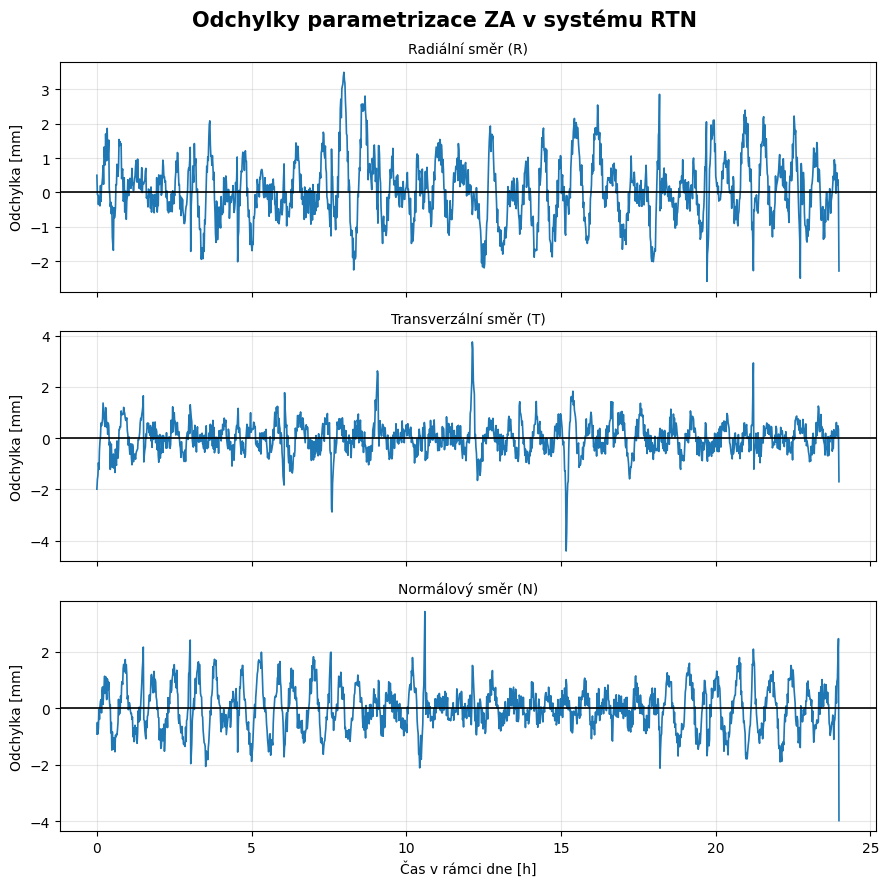

In [13]:
# ============================================================
# 13) RTN RESIDUALS FOR ONE DAY
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, (col, title) in zip(axes, components):
    ax.plot(day_df["time_h"], day_df[col], linewidth=1.2)
    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Odchylka [mm]")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Čas v rámci dne [h]")
fig.suptitle(
    f"Odchylky parametrizace {SOLUTION} v systému RTN",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
_sat = (SAT or "all").lower()
fig.savefig(PLOTS_DIR / f"{_sat}_{SOLUTION.lower()}_rtn_residuals_doy{selected_doy:03d}_iter{ITERATION}.pdf", bbox_inches="tight")
plt.show()

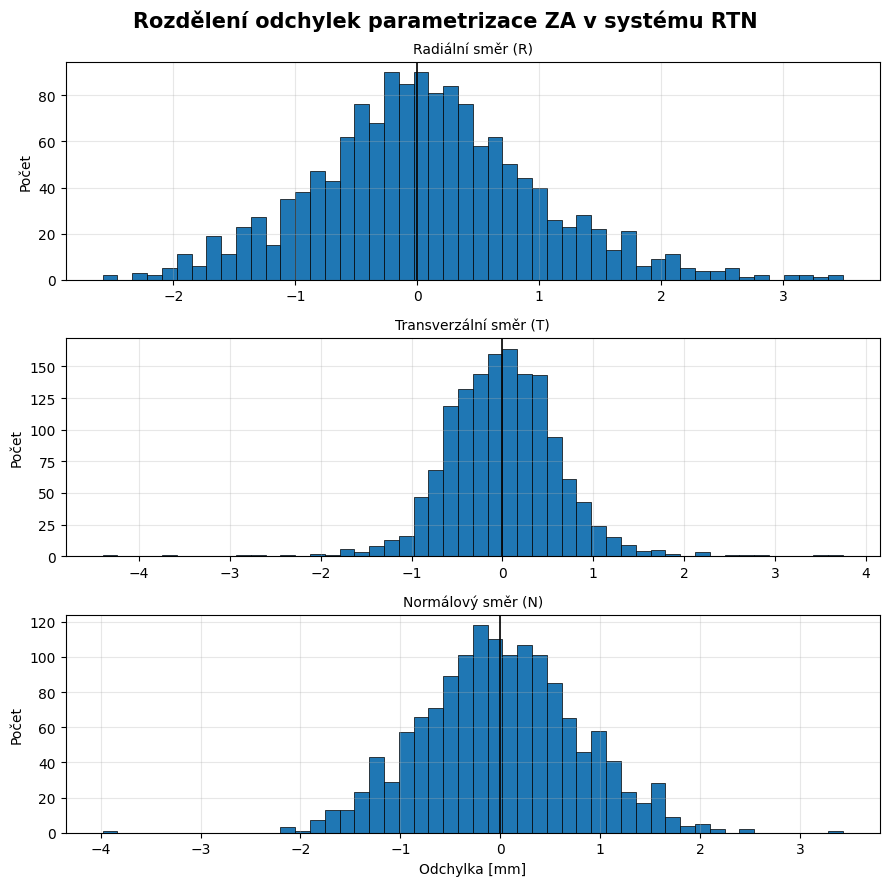

In [14]:
# ============================================================
# 14) RTN RESIDUAL HISTOGRAMS FOR ONE DAY
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(9, 9))

for ax, (col, title) in zip(axes, components):
    ax.hist(day_df[col], bins=50, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Počet")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Odchylka [mm]")
fig.suptitle(
    f"Rozdělení odchylek parametrizace {SOLUTION} v systému RTN",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
_sat = (SAT or "all").lower()
fig.savefig(PLOTS_DIR / f"{_sat}_{SOLUTION.lower()}_rtn_histograms_doy{selected_doy:03d}_iter{ITERATION}.pdf", bbox_inches="tight")
plt.show()

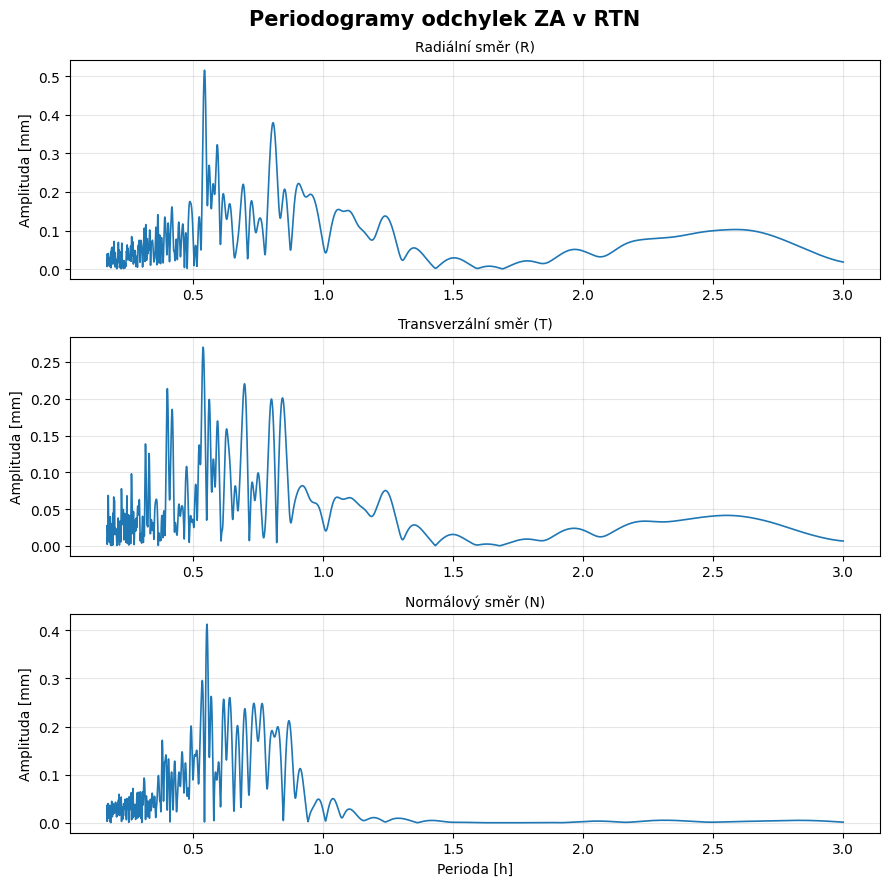

In [15]:
# ============================================================
# 15) RTN RESIDUAL PERIODOGRAMS FOR ONE DAY
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(9, 9))

for ax, (col, title) in zip(axes, components):
    pg = compute_periodogram(
        day_df, method="lomb_scargle", time_col="t_sec",
        value_cols=col, min_period=600, max_period=10800,
    )
    ax.plot(pg["period"] / 3600, pg["amplitude"], linewidth=1.2)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Amplituda [mm]")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Perioda [h]")
fig.suptitle(
    f"Periodogramy odchylek {SOLUTION} v RTN",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
_sat = (SAT or "all").lower()
fig.savefig(PLOTS_DIR / f"{_sat}_{SOLUTION.lower()}_rtn_periodograms_doy{selected_doy:03d}_iter{ITERATION}.pdf", bbox_inches="tight")
plt.show()

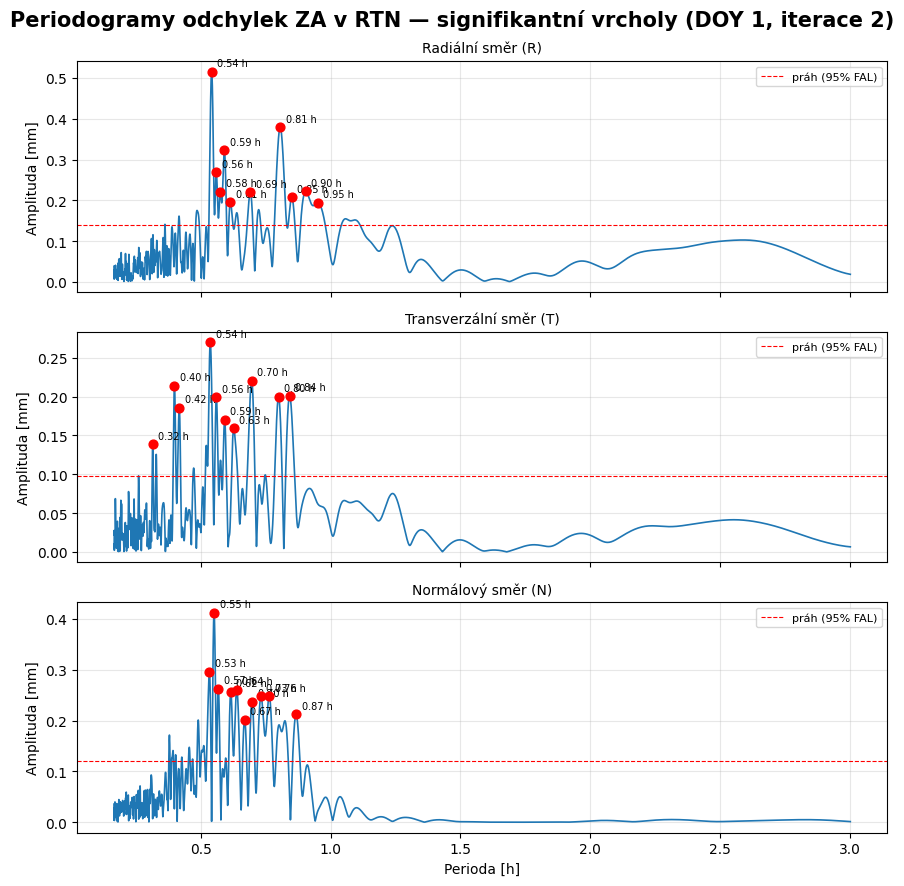

Signifikantní vrcholy:

Radiální směr (R):


,period_h,amplitude
0,0.542372,0.514929
1,0.806353,0.379180
2,0.591462,0.322079
3,0.560462,0.268797
4,0.904918,0.221867
5,0.575701,0.221089
6,0.691527,0.219670
7,0.850399,0.206964
8,0.614820,0.195417
9,0.950412,0.193853



Transverzální směr (T):


,period_h,amplitude
0,0.537144,0.270042
1,0.696532,0.220292
2,0.399507,0.213713
3,0.842280,0.201105
4,0.800258,0.199538
5,0.560759,0.199055
6,0.417961,0.185499
7,0.592455,0.169788
8,0.627576,0.158911
9,0.315366,0.138547



Normálový směr (N):


,period_h,amplitude
0,0.551700,0.412649
1,0.533893,0.295724
2,0.568284,0.262654
3,0.639325,0.260252
4,0.616251,0.256838
5,0.732181,0.248344
6,0.763879,0.248018
7,0.697910,0.237075
8,0.867116,0.212218
9,0.669232,0.201960


In [16]:
# ============================================================
# 16) PERIODOGRAM — SIGNIFICANT PEAKS
# ============================================================

# False-alarm level for the permutation threshold (0.95 = 5% false-alarm rate).
# More permutations = more accurate threshold but slower.
FALSE_ALARM = 0.95
N_PERMUTATIONS = 100

if day_df.empty:
    print("Žádná data.")
else:
    # Compute periodograms, thresholds and peaks for each component.
    results = {}
    for col, _ in components:
        pg = compute_periodogram(
            day_df, method="lomb_scargle", time_col="t_sec",
            value_cols=col, min_period=600, max_period=10800,
        )
        pg["period_h"] = pg["period"] / 3600

        threshold = estimate_periodogram_threshold(
            day_df, method="lomb_scargle", time_col="t_sec", value_cols=col,
            false_alarm_level=FALSE_ALARM, n_permutations=N_PERMUTATIONS,
            min_period=600, max_period=10800,
        )
        peaks = find_significant_peaks(pg, threshold=threshold)
        results[col] = {"pg": pg, "threshold": threshold, "peaks": peaks}

    # Plot.
    fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

    for ax, (col, title) in zip(axes, components):
        pg = results[col]["pg"]
        threshold = results[col]["threshold"]
        peaks = results[col]["peaks"]

        ax.plot(pg["period_h"], pg["amplitude"], linewidth=1.2)
        ax.axhline(threshold, color="red", linewidth=0.8, linestyle="--",
                   label=f"práh ({FALSE_ALARM:.0%} FAL)")

        if not peaks.empty:
            ax.scatter(peaks["period_h"], peaks["amplitude"], color="red", s=40, zorder=5)
            for _, row in peaks.iterrows():
                ax.annotate(
                    f"{row['period_h']:.2f} h",
                    xy=(row["period_h"], row["amplitude"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=7,
                )

        ax.set_title(title, fontsize=10)
        ax.set_ylabel("Amplituda [mm]")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Perioda [h]")
    fig.suptitle(
        f"Periodogramy odchylek {SOLUTION} v RTN — signifikantní vrcholy (DOY {selected_doy}, iterace {ITERATION})",
        fontsize=15, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Summary table of significant peaks.
    print("Signifikantní vrcholy:")
    for col, title in components:
        peaks = results[col]["peaks"]
        if not peaks.empty:
            print(f"\n{title}:")
            display(peaks[["period_h", "amplitude"]].reset_index(drop=True))
        else:
            print(f"\n{title}: žádné signifikantní vrcholy")